This sprint is meant to take this week's flu and temp data and predict next week's case count. Lag features will be tackled here.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Loading merged flu + climate data from Sprint 3
df = pd.read_csv('../data/sprint3_merged.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Loaded {len(df)} weeks of merged data")
print(f"Data range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 157 weeks of merged data
Data range: 2014-09-01 to 2017-08-21
Columns: ['date', 'season', 'TotalFluPositive', 'mean_temp', 'total_precip', 'total_snow']


,date,season,TotalFluPositive,mean_temp,total_precip,total_snow
0,2014-09-01,2014-2015,5.0,21.185714,43.4,0.0
1,2014-09-08,2014-2015,4.0,15.857143,16.2,0.0
2,2014-09-15,2014-2015,15.0,14.328571,30.6,0.0
3,2014-09-22,2014-2015,19.0,16.957143,0.0,0.0
4,2014-09-29,2014-2015,26.0,15.500000,9.7,0.0


In [5]:
# Feature engineering to create lag features. The model will use past values to predict the future
df_features  =df.copy()

# Flu case lags - what happened 1,2 and 3 weeks ago
df_features['flu_lag1'] = df_features['TotalFluPositive'].shift(1)
df_features['flu_lag2'] = df_features['TotalFluPositive'].shift(2)
df_features['flu_lag3'] = df_features['TotalFluPositive'].shift(3)
df_features['flu_lag4'] = df_features['TotalFluPositive'].shift(4)

# Temp lags - cold weather this week that affects cases next week
df_features['temp_lag1'] = df_features['mean_temp'].shift(1)
df_features['temp_lag2'] = df_features['mean_temp'].shift(2)

# Rolling average - smoothed trend over last 4 weeks. Captures whether cases are generally rising or falling
df_features['flu_rolling4'] = (
    df_features['TotalFluPositive'].shift(1).rolling(4).mean()
)

# Current week climate
df_features['temp_current'] = df_features['mean_temp']
df_features['precip_current'] = df_features['total_precip']

# Week of year - captures seasonality directly
df_features['week_of_year'] = df_features['date'].dt.isocalendar().week.astype(int)

# Drop rows with NaN created by shifting
df_features = df_features.dropna().reset_index(drop=True)

print(f"Rows after feature engineering: {len(df_features)}")
print(f"Date range: {df_features['date'].min().date()}"
      f"to {df_features['date'].max().date()}")
print()
print("Feature columns created:")
feature_cols = [
    'flu_lag1', 'flu_lag2', 'flu_lag3', 'flu_lag4', 'temp_lag1', 'temp_lag2', 'temp_current',
    'precip_current', 'flu_rolling4', 'week_of_year'
]

for f in feature_cols:
    print(f" {f}")


Rows after feature engineering: 153
Date range: 2014-09-29to 2017-08-21

Feature columns created:
 flu_lag1
 flu_lag2
 flu_lag3
 flu_lag4
 temp_lag1
 temp_lag2
 temp_current
 precip_current
 flu_rolling4
 week_of_year


Lost the 4 rows from the top because the 4-week lag needs 4 weeks of historyy before they can produce a value. 

In [8]:
# Define features and target
feature_cols = [
    'flu_lag1', 'flu_lag2', 'flu_lag3', 'flu_lag4', 'temp_lag1', 'temp_lag2', 'temp_current',
    'precip_current', 'flu_rolling4', 'week_of_year'
]

target_col = 'TotalFluPositive'

# Time-series split - NEVER shuffle time series data. 
# Training: 2014-2015 and 2015-2016 seasons
# Testing: 2016-2017 (the model has never seen this)
train = df_features[df_features['season'] != '2016-2017'].copy()
test = df_features[df_features['season'] == '2016-2017'].copy()

x_train = train[feature_cols]
y_train = train[target_col]

x_test = test[feature_cols]
y_test = test[target_col]

print(f"Training rows: {len(train)}")
print(f"Test rows: {len(test)}")
print()
print(f"Training period: {train['date'].min().date()}"
      f" to {train['date'].max().date()}")
print(f"Test period: {test['date'].min().date()}"
        f" to {test['date'].max().date()}")

Training rows: 101
Test rows: 52

Training period: 2014-09-29 to 2016-08-22
Test period: 2016-08-29 to 2017-08-21


Time series data is never shuffled because the model will experience data leakage. It will have insight on what its meant to predict and as such, it will perform as though it is actually accurate.

In [9]:
# Training the XGBoost model
model = XGBRegressor(
    n_estimators=200,       # number of trees to build
    learning_rate=0.05,     # how much each tree corrects the previous
    max_depth=4,            # how deep each tree can grow
    subsample=0.8,          # fraction of data used per tree
    random_state=42,        # ensures reproducible results
    verbosity=0  
)

model.fit(x_train, y_train)

print("Model trained successfully")
print(f"Number of trees built: {model.n_estimators}")
print(f"Features used: {len(feature_cols)}")

Model trained successfully
Number of trees built: 200
Features used: 10


The trees built are called weak learners - each tree is small and weak on its own but they build on each other to produce a powerful combined prediction. This is technique is called gradient boosting. The XG in XGBoost stands for Extreme Gradient Boosting

The learning rate is set to 0.05. This controsl how aggressively each tree corrects the previous one. A small learning rate warrants caution, but learning is slow. A high learning rate learns quickly but may overcorrect and miss the true pattern.

In [10]:
# Making predictions on the test set
y_pred = model.predict(x_test)

# Calculating error metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) /  y_test.replace(0, np.nan))) * 100

print("Model performance on 2016-2017 season (never seen during testing): ")
print(f" MAE: {mae:.1f} cases")
print(f" RMSE: {rmse:.1f} cases")
print(f" MAPE: {mape:.1f}%")
print()
print("What these mean: ")
print(f" On average the model is off by {mae:.0f} cases per week")
print(f" The worst errors are weighted at {rmse:.0f} cases (RMSE)")
print(f" As a percentange of actual cases, error is {mape:.1f}%")

Model performance on 2016-2017 season (never seen during testing): 
 MAE: 226.2 cases
 RMSE: 440.5 cases
 MAPE: 41.3%

What these mean: 
 On average the model is off by 226 cases per week
 The worst errors are weighted at 441 cases (RMSE)
 As a percentange of actual cases, error is 41.3%


Mean Absolute Error (MAE) - on average, my prediction is 226 cases away from reality each week. During summer when cases are near zero, 226 cases off is enormous. During January peak when cases hit 3,700, 226 cases off is only 6% off. This is because MAE treats all weeks equally regardless of outbreak size.

Rooot Mean Squared Error (RMSE) - higher the MAE because it squares the errors before averaging which punishes large mistakes more heavily than small one. The difference between the MAE and RMSE shows that my model has a few very bad weeks pulling the RMSE up. This is probably during the peak.

Mean Absolute Percentage Error (MAPE) - on average the model's prediction is 41% away from the real value. The target is 20%.
The number is heavily distorted due to summer when the number is nearly zero; even being off by 10 cases when reality is 5 cases gives a 200% error for that week. Failure to master this season, the MAPE will always be bad.

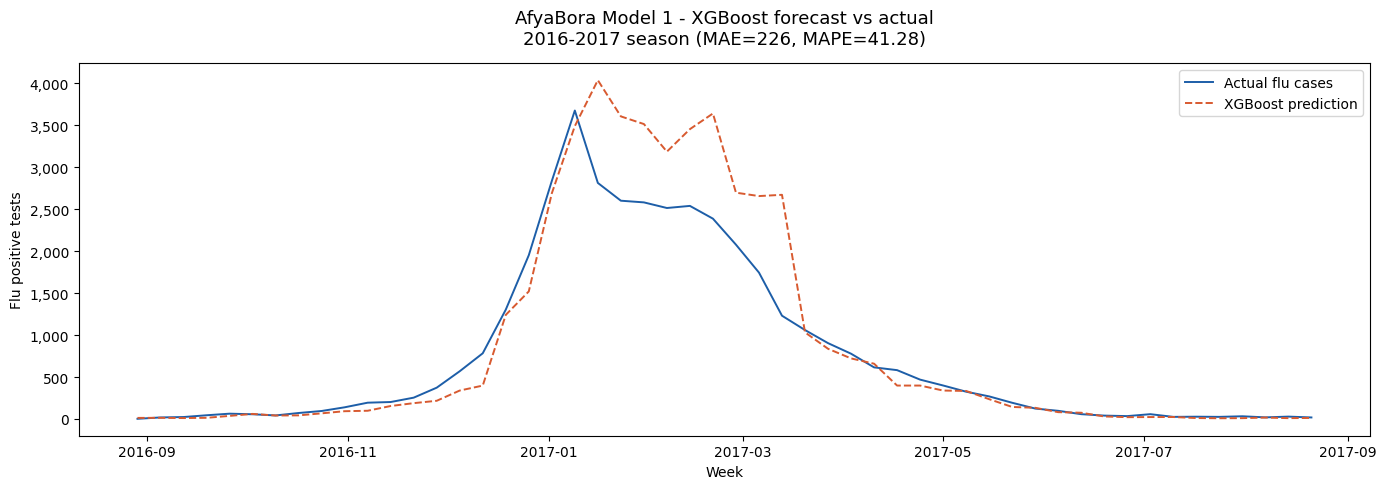

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test['date'], y_test, color='#1D5EA8', linewidth=1.4, label='Actual flu cases')
ax.plot(test['date'], y_pred, color='#D85A30', linewidth=1.4, linestyle='--', label='XGBoost prediction')
ax.set_title(f'AfyaBora Model 1 - XGBoost forecast vs actual\n'
             f'2016-2017 season (MAE={mae:.0f}, MAPE={mape:.2f})', fontsize=13, pad=14)

ax.set_xlabel('Week')
ax.set_ylabel('Flu positive tests')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.savefig('../data/sprint4_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

The model is able to predict accurately when the cases are low in 2016 September to November and when the outbreak breaks in 2017 June to August.

There are three possible reasons why the model fails at the peak.
1. Reason 1 - the double hump problem
    The model is yet to see a double hump season that was the case in 2016-2017. 2014-2016 only had singular peaks. So when it sees the real data dipping in Feb, the mode thinks the outbreak is ending hence predicting a high second peak that doesn't match reality. The model is generalizing from patterns it knows not patterns actually happening.

2. Reason 2 - peak magnitude overshoot
    The model precits ~4,050 cases at peak when reality was ~3,670, an overestimation of about 400 cases.This is beacause it learned from the '15-'16 season which peaked at ~4,600 the highest peak in my dataset. It's anchoring its peak prediction to the largest outbreak it's seen.

3. Reason 3 - small training set
    101 weeks across two seasons does not give XGBoost enough variety to generalize well. The model might be memorizing patterns than learning universal outbreak dynamics.

The MAPE of 41.3% robs what the model actually does. It correctly identifies that an outbreak is coming weeks before the peak; gets the timing right, the rise starts in the right month and the magnitude is roughly right within 10% at peak. It correctly predicts the decline.

For a public health early warning system, the most important question is not "how precisely did we predict the exact case count?" but "did we give health authorities enough warning to prepare?". By that measure, this model is already useful.

That is the difference between statistical accuracy and operational utility something my concept paper and governance layer needs to address explicity.

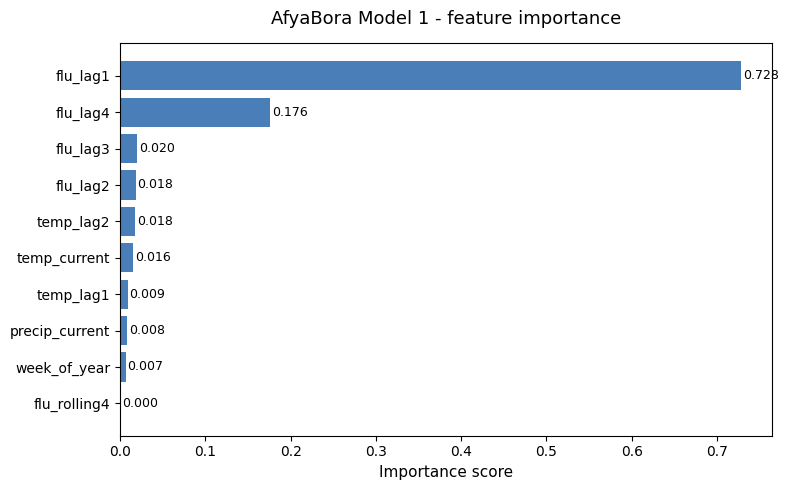

In [15]:
# Feature importance - tells me which inputs the model relied on most
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}). sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(importance['feature'], importance['importance'], color='#1D5EA8', alpha=0.8)

ax.set_xlabel('Importance score', fontsize=11)
ax.set_title('AfyaBora Model 1 - feature importance', fontsize=13, pad=14)

# Adding value labels on bars
for bar, val in zip(bars, importance['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
    f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/sprint4_importance.png', dpi=150, bbox_inches='tight')
plt.show()

This model is currenyly an autoaggressive model - it predicts the future from the past values of the same variable. 72.8% of the model's predictive power comes from one feature, what happened last week.

The model could benefit from more seasons of historical data, more climate variables and population-level features like vaccination rates and mobility data. These would reduce the dominance of flu_lag1 and increase the climate signal.

For learning log:
While flu_lag1 has such weight, temp_lag1 doesn't. This is because once the infection breaks, it becomes self sufficient regardless of the temp. The temp is an ignition, not fuel. In September and October, the cases are near zero and flu_lag1 carries almost no info. At this point, a sudeen cold dnap is the strongest signal available that an outbreak may be coming.

 During the outbreak itself, December through March, flu_lag1 takes over because the disease dynamics dominate the climate signal. This is why AB needs both signals working together rather than either alone.

In [16]:
# Saving merged dataset with features for Sprint 5
df_features.to_csv('../data/sprint4_features.csv', index=False)

# Saving predictions for the report
results = pd.DataFrame({
    'date': test['date'].values,
    'actual': y_test.values,
    'predicted': y_pred
})

results.to_csv('../data/sprint4_predictions.csv', index=False)

import json
sprint4_metrics = {
    'mae': round(mae, 2),
    'rmse': round(rmse, 2),
    'mape': round(mape, 2),
    'top_feature': 'flu_lag1',
    'top_feature_importance': round(float(model.feature_importances_[0]), 3)
}

with open('../data/sprint4_results.json', 'w') as f:
    json.dump(sprint4_metrics, f)

print("Sprint 4 outputs saved: ")
print(" data/sprint4_features.csv")
print(" data/sprint4_predictions.csv")
print(" data/sprint4_results.json")

Sprint 4 outputs saved: 
 data/sprint4_features.csv
 data/sprint4_predictions.csv
 data/sprint4_results.json
